In [28]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
!nvidia-smi

Sat May  2 11:45:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.83                 Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   63C    P8              3W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
# image data generator is the package to lebel the image & it will automatically label all the images

In [ ]:
img =image.load_img(r'D:\ABHI-VSCODE\DEEPLEARNING\Training\Happy\happy img -6.jpg')

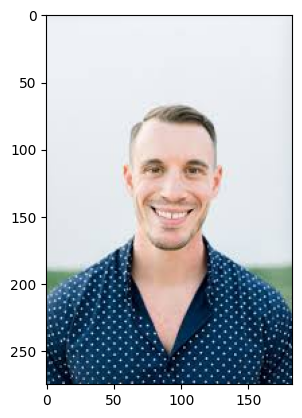

In [ ]:
plt.imshow(img)

In [ ]:
i1=cv2.imread('D:\ABHI-VSCODE\DEEPLEARNING\Training\Happy\happy img -6.jpg')
i1
# 3 dimension metrics are created for the image
# the value ranges from 0-255

array([[[240, 235, 232],
        [240, 235, 232],
        [240, 235, 232],
        ...,
        [239, 234, 231],
        [239, 234, 231],
        [238, 233, 230]],

       [[240, 235, 232],
        [240, 235, 232],
        [240, 235, 232],
        ...,
        [239, 234, 231],
        [239, 234, 231],
        [238, 233, 230]],

       [[241, 236, 233],
        [241, 236, 233],
        [241, 236, 233],
        ...,
        [239, 234, 231],
        [239, 234, 231],
        [238, 233, 230]],

       ...,

       [[ 61,  34,   0],
        [ 87,  60,  26],
        [ 74,  47,  13],
        ...,
        [ 64,  36,   5],
        [ 69,  41,  10],
        [ 53,  25,   0]],

       [[ 82,  54,  23],
        [149, 121,  90],
        [165, 137, 106],
        ...,
        [ 46,  18,   0],
        [ 58,  30,   0],
        [ 66,  37,   6]],

       [[ 80,  52,  21],
        [137, 109,  78],
        [146, 118,  87],
        ...,
        [124,  96,  65],
        [ 74,  46,  15],
        [ 60,  31,   0]]

In [ ]:
i1.shape
# shape of your image height,weight ,rgb

(275, 183, 3)

In [ ]:
train = ImageDataGenerator(rescale=1/200)
validation =ImageDataGenerator(rescale =1/200)

#to scale all the images i need to devided with 255
#we need to resize the image using 200,200 pixel


In [ ]:
train_dataset = train.flow_from_directory(
    "D:\ABHI-VSCODE\DEEPLEARNING\Training",
    target_size = (200,200),
    batch_size = 3,
    class_mode = 'binary'
)
validation_dataset =validation.flow_from_directory(
    "D:\ABHI-VSCODE\DEEPLEARNING\Validation",
    target_size = (200,200),
    batch_size = 3,
    class_mode = 'binary'
)

Found 29 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [ ]:
train_dataset.classes
#15 zeros --happy
#15 ones -- sad/not happy

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1])

In [ ]:
# now we are applying maxpooling
model =tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),
    #
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    #
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    #
    tf.keras.layers.Flatten(),
    #
    tf.keras.layers.Dense(512,activation='relu'),
    #
    tf.keras.layers.Dense(1,activation='sigmoid')
])

c:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001)
)

In [ ]:
model_fit = model.fit(train_dataset,epochs =8)

Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - loss: 1.7614
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - loss: 0.7018
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - loss: 1.1864
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - loss: 0.6991
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.4944
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - loss: 0.5499
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - loss: 0.4053
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - loss: 0.2258


In [29]:
dir_path ='D:\ABHI-VSCODE\DEEPLEARNING\Testing'
for i in os.listdir(dir_path):
  print(i)
  #img =image.load_img(dir_path+'//'+i,target_size=(200,200))
  #plt.imshow(img)
  #plt.show()

In [32]:
dir_path ='D:\ABHI-VSCODE\DEEPLEARNING\Testing'
for i in os.listdir(dir_path):
  print(i)
  img =image.load_img(dir_path+'//'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()

  x =image.img_to_array(img)
  x=np.expand_dims(x,axis=0)
  images =np.vstack([x])

  val =model.predict(images)
  if val ==0:
    print('i am happy')
  else:
    print('i am not happy')


In [33]:
import gradio as gd
import numpy as np
from PIL import Image

def predict_mood(image):
  # Resize the image to(200,200)as expected by the model
  img =image.resize((200,200))
  #Convert the image to numpy array
  x=np.array(img)
  #Expand dimension to create a batch of 1 image
  x = np.expand_dims(x,axis=0)
  #Expand the dimensions to match the model's input shape
  #The model was trained with rescale=1/200 ,so we should apply the same scalling here.
  x=x/200.0
  #Make prediction
  val= model.predict(x)[0][0]
  #interoret the prediction
  if val<0.5:
    return 'Happy'
  else:
    return 'Not Happy'


ModuleNotFoundError: No module named 'gradio'

In [ ]:
iface = gd.Interface(fn=predict_mood,
                     inputs=gd.Image(type='pil', label='Upload an image'),
                     outputs=gd.Text(label='Predicted Mood'),
                     title='Mood Classification (Happy/Not Happy)',
                     description='Upload an image to classify if the person is happy or not happy')

NameError: name 'gd' is not defined

In [ ]:
iface.launch()

NameError: name 'iface' is not defined